# Neural Network Implementation from Scratch

**Student Name:** Suyash Hadole  
**PRN Number:** 202401110055  
**Course:** Generative AI Lab  
**Department:** CSE (AIML)  
**Class:** T.Y. Tech  

---

## Objective

Implement a simple feedforward neural network from scratch in Python without using in-built deep learning libraries. The implementation demonstrates the **forward pass, backpropagation, cross-entropy loss, and gradient descent**.

To satisfy the evaluation requirements, two neural-network architectures are implemented and compared:
- **Model 1:** Shallow neural network
- **Model 2:** Deeper neural network

The comparison includes accuracy, loss, confusion matrices, training curves, and interpretation of the results.


## 1. Problem Definition

### Dataset
The **Iris dataset** is used. It contains measurements of iris flowers from three classes:
- Setosa
- Versicolor
- Virginica

Each sample has four numerical input features:
1. Sepal length
2. Sepal width
3. Petal length
4. Petal width

### Task
This is a **multi-class classification** problem. The neural network predicts one of the three Iris flower classes from the four input features.

### Why Iris?
Iris is compact and suitable for demonstrating the complete neural-network learning process from scratch. It allows the mathematical operations of forward propagation and backpropagation to be implemented and analyzed clearly.


## 2. Methodology

### Neural Network Architecture

Two models are evaluated.

**Model 1 – Shallow Network**
- Input layer: 4 neurons
- Hidden layer: 8 neurons
- Output layer: 3 neurons
- Hidden activation: ReLU
- Output activation: Softmax

**Model 2 – Deep Network**
- Input layer: 4 neurons
- Hidden layer 1: 16 neurons
- Hidden layer 2: 8 neurons
- Output layer: 3 neurons
- Hidden activation: ReLU
- Output activation: Softmax

### Forward Pass
For each layer:

`Z = XW + b`

The activation function is then applied. ReLU is used in hidden layers and softmax is used at the output layer.

### Loss Function
Categorical cross-entropy is used because the task is multi-class classification.

### Backpropagation
The gradient of the loss is propagated backward through each layer using the chain rule. The weights and biases are updated using gradient descent.

### Optimization
Batch gradient descent is used:

`W = W - learning_rate × dW`

`b = b - learning_rate × db`


In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

np.random.seed(42)

iris = load_iris()
X = iris.data.astype(np.float64)
y = iris.target.astype(int)
class_names = iris.target_names

print("Dataset shape:", X.shape)
print("Classes:", class_names)
print("Class distribution:", np.bincount(y))


Dataset shape: (150, 4)
Classes: ['setosa' 'versicolor' 'virginica']
Class distribution: [50 50 50]


In [ ]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

num_classes = len(np.unique(y))
Y_train = np.eye(num_classes)[y_train]

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])
print("Input features:", X_train.shape[1])


Training samples: 120
Testing samples: 30
Input features: 4


## 3. Neural Network From Scratch


In [3]:
class NeuralNetworkFromScratch:
    def __init__(self, layer_sizes, learning_rate=0.05, epochs=1500, seed=42):
        self.layer_sizes = layer_sizes
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.rng = np.random.default_rng(seed)
        self.weights = []
        self.biases = []
        self.loss_history = []

        # He initialization for layers followed by ReLU
        for i in range(len(layer_sizes) - 1):
            fan_in = layer_sizes[i]
            fan_out = layer_sizes[i + 1]
            W = self.rng.normal(0, np.sqrt(2 / fan_in), (fan_in, fan_out))
            b = np.zeros((1, fan_out))
            self.weights.append(W)
            self.biases.append(b)

    @staticmethod
    def relu(z):
        return np.maximum(0, z)

    @staticmethod
    def relu_derivative(z):
        return (z > 0).astype(float)

    @staticmethod
    def softmax(z):
        z_shifted = z - np.max(z, axis=1, keepdims=True)
        exp_z = np.exp(z_shifted)
        return exp_z / np.sum(exp_z, axis=1, keepdims=True)

    @staticmethod
    def cross_entropy(y_true_onehot, y_pred):
        eps = 1e-12
        y_pred = np.clip(y_pred, eps, 1 - eps)
        return -np.mean(np.sum(y_true_onehot * np.log(y_pred), axis=1))

    def forward(self, X):
        activations = [X]
        pre_activations = []
        A = X

        for i in range(len(self.weights) - 1):
            Z = A @ self.weights[i] + self.biases[i]
            A = self.relu(Z)
            pre_activations.append(Z)
            activations.append(A)

        Z_out = A @ self.weights[-1] + self.biases[-1]
        output = self.softmax(Z_out)
        pre_activations.append(Z_out)
        activations.append(output)

        return activations, pre_activations

    def backward(self, X, y_onehot, activations, pre_activations):
        m = X.shape[0]
        grad_W = [None] * len(self.weights)
        grad_b = [None] * len(self.biases)

        # Softmax + cross-entropy derivative
        dZ = (activations[-1] - y_onehot) / m

        for i in reversed(range(len(self.weights))):
            grad_W[i] = activations[i].T @ dZ
            grad_b[i] = np.sum(dZ, axis=0, keepdims=True)

            if i > 0:
                dA_prev = dZ @ self.weights[i].T
                dZ = dA_prev * self.relu_derivative(pre_activations[i - 1])

        return grad_W, grad_b

    def fit(self, X, y_onehot, verbose=True):
        self.loss_history = []

        for epoch in range(self.epochs):
            activations, pre_activations = self.forward(X)
            loss = self.cross_entropy(y_onehot, activations[-1])
            self.loss_history.append(loss)

            grad_W, grad_b = self.backward(
                X, y_onehot, activations, pre_activations
            )

            for i in range(len(self.weights)):
                self.weights[i] -= self.learning_rate * grad_W[i]
                self.biases[i] -= self.learning_rate * grad_b[i]

            if verbose and (epoch + 1) % 300 == 0:
                print(f"Epoch {epoch + 1:4d}/{self.epochs} - Loss: {loss:.4f}")

        return self

    def predict_proba(self, X):
        activations, _ = self.forward(X)
        return activations[-1]

    def predict(self, X):
        return np.argmax(self.predict_proba(X), axis=1)


## 4. Model 1 – Shallow Neural Network

This model contains one hidden layer. It is used as a baseline to understand how a relatively simple architecture performs on the classification problem.


In [4]:
model1 = NeuralNetworkFromScratch(
    layer_sizes=[4, 8, 3],
    learning_rate=0.05,
    epochs=1500,
    seed=42
)

model1.fit(X_train, Y_train)

pred1 = model1.predict(X_test)
acc1 = accuracy_score(y_test, pred1)

print(f"Model 1 Test Accuracy: {acc1 * 100:.2f}%")
print("\nClassification Report - Model 1")
print(classification_report(y_test, pred1, target_names=class_names, digits=4))


Epoch  300/1500 - Loss: 0.2055
Epoch  600/1500 - Loss: 0.1118
Epoch  900/1500 - Loss: 0.0795
Epoch 1200/1500 - Loss: 0.0647
Epoch 1500/1500 - Loss: 0.0566
Model 1 Test Accuracy: 96.67%

Classification Report - Model 1
              precision    recall  f1-score   support

      setosa     1.0000    1.0000    1.0000        10
  versicolor     1.0000    0.9000    0.9474        10
   virginica     0.9091    1.0000    0.9524        10

    accuracy                         0.9667        30
   macro avg     0.9697    0.9667    0.9666        30
weighted avg     0.9697    0.9667    0.9666        30



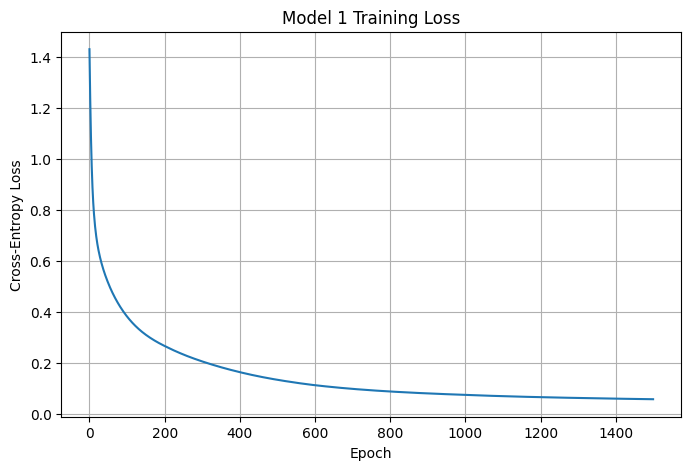

In [5]:
plt.figure(figsize=(8, 5))
plt.plot(model1.loss_history)
plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")
plt.title("Model 1 Training Loss")
plt.grid(True)
plt.show()


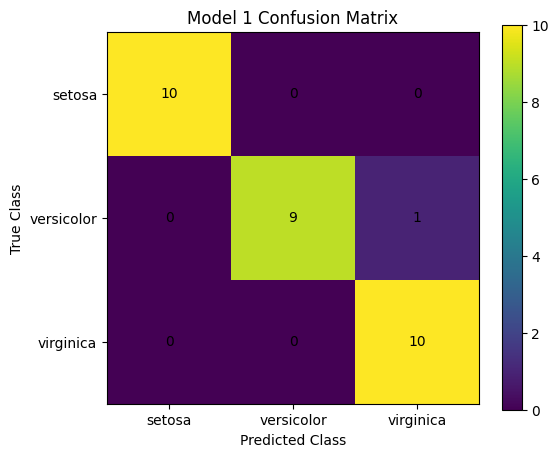

In [6]:
cm1 = confusion_matrix(y_test, pred1)

plt.figure(figsize=(6, 5))
plt.imshow(cm1)
plt.title("Model 1 Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.xticks(range(3), class_names)
plt.yticks(range(3), class_names)

for i in range(3):
    for j in range(3):
        plt.text(j, i, cm1[i, j], ha="center", va="center")

plt.colorbar()
plt.show()


## 5. Model 2 – Deeper Neural Network

The second model contains two hidden layers. The purpose is to examine whether a deeper architecture can learn the classification boundaries more effectively than the shallow baseline.


In [7]:
model2 = NeuralNetworkFromScratch(
    layer_sizes=[4, 16, 8, 3],
    learning_rate=0.05,
    epochs=1500,
    seed=42
)

model2.fit(X_train, Y_train)

pred2 = model2.predict(X_test)
acc2 = accuracy_score(y_test, pred2)

print(f"Model 2 Test Accuracy: {acc2 * 100:.2f}%")
print("\nClassification Report - Model 2")
print(classification_report(y_test, pred2, target_names=class_names, digits=4))


Epoch  300/1500 - Loss: 0.0932
Epoch  600/1500 - Loss: 0.0525
Epoch  900/1500 - Loss: 0.0406
Epoch 1200/1500 - Loss: 0.0346
Epoch 1500/1500 - Loss: 0.0307
Model 2 Test Accuracy: 96.67%

Classification Report - Model 2
              precision    recall  f1-score   support

      setosa     1.0000    1.0000    1.0000        10
  versicolor     1.0000    0.9000    0.9474        10
   virginica     0.9091    1.0000    0.9524        10

    accuracy                         0.9667        30
   macro avg     0.9697    0.9667    0.9666        30
weighted avg     0.9697    0.9667    0.9666        30



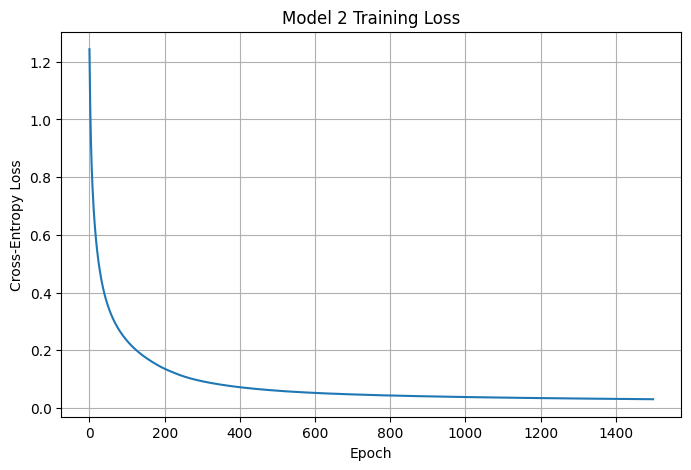

In [8]:
plt.figure(figsize=(8, 5))
plt.plot(model2.loss_history)
plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")
plt.title("Model 2 Training Loss")
plt.grid(True)
plt.show()


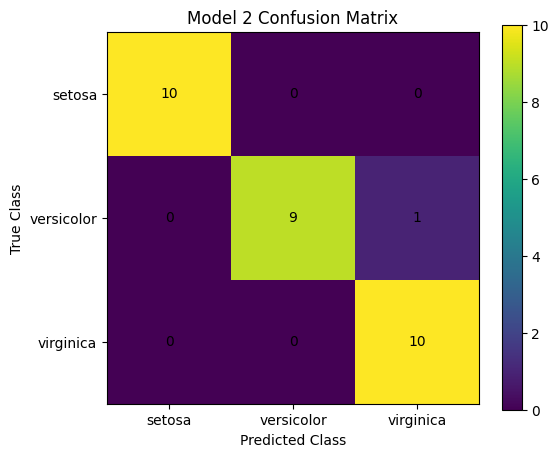

In [9]:
cm2 = confusion_matrix(y_test, pred2)

plt.figure(figsize=(6, 5))
plt.imshow(cm2)
plt.title("Model 2 Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.xticks(range(3), class_names)
plt.yticks(range(3), class_names)

for i in range(3):
    for j in range(3):
        plt.text(j, i, cm2[i, j], ha="center", va="center")

plt.colorbar()
plt.show()


## 6. Performance Comparison

The two architectures are compared using test accuracy and final training loss. This provides a direct evaluation of whether the deeper model offers a meaningful improvement over the shallow model.


In [10]:
results = {
    "Model 1 - Shallow [4,8,3]": {
        "Test Accuracy (%)": acc1 * 100,
        "Final Training Loss": model1.loss_history[-1]
    },
    "Model 2 - Deep [4,16,8,3]": {
        "Test Accuracy (%)": acc2 * 100,
        "Final Training Loss": model2.loss_history[-1]
    }
}

for name, values in results.items():
    print(name)
    print(f"  Test Accuracy: {values['Test Accuracy (%)']:.2f}%")
    print(f"  Final Training Loss: {values['Final Training Loss']:.4f}")


Model 1 - Shallow [4,8,3]
  Test Accuracy: 96.67%
  Final Training Loss: 0.0566
Model 2 - Deep [4,16,8,3]
  Test Accuracy: 96.67%
  Final Training Loss: 0.0307


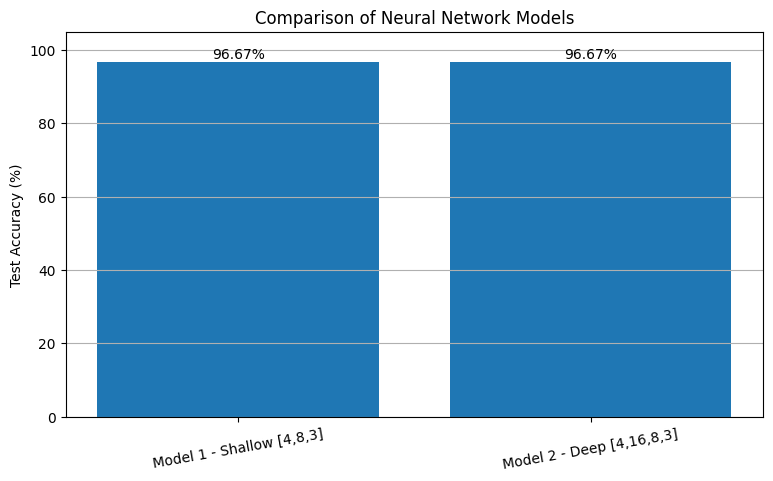

In [11]:
names = list(results.keys())
accuracies = [results[n]["Test Accuracy (%)"] for n in names]

plt.figure(figsize=(9, 5))
bars = plt.bar(names, accuracies)
plt.ylabel("Test Accuracy (%)")
plt.title("Comparison of Neural Network Models")
plt.ylim(0, 105)

for bar, value in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, value + 1, f"{value:.2f}%",
             ha="center")

plt.xticks(rotation=10)
plt.grid(axis="y")
plt.show()


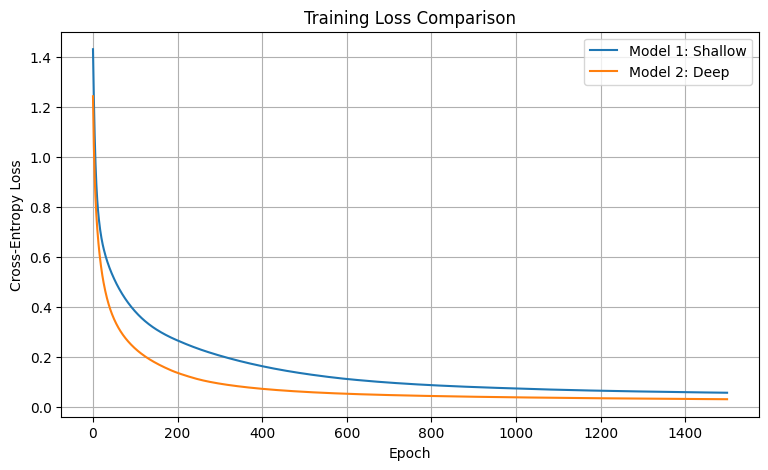

In [12]:
plt.figure(figsize=(9, 5))
plt.plot(model1.loss_history, label="Model 1: Shallow")
plt.plot(model2.loss_history, label="Model 2: Deep")
plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")
plt.title("Training Loss Comparison")
plt.legend()
plt.grid(True)
plt.show()


## 7. Analysis of the Implemented Models

### Model 1
The shallow model provides a strong baseline with only one hidden layer. Its relatively small number of parameters makes it simple and computationally efficient. The loss curve should decrease as gradient descent updates the weights.

### Model 2
The deeper model introduces an additional hidden layer and more neurons. This increases the representational capacity of the network and allows it to learn more complex transformations.

### Comparison
The final comparison should be interpreted using the actual execution results above. A higher test accuracy indicates better classification performance on unseen data, while a lower final loss indicates that the model fitted the training data more effectively.

The deeper model is not automatically superior. If both models obtain similar test accuracy, the shallow model may be preferable because it is simpler and requires fewer parameters. If the deeper model produces a clear accuracy improvement without unstable training, its additional capacity is justified for this dataset.



## 8. Understanding the Learning Process

The complete learning cycle is:

**Input → Weighted Sum → ReLU → Weighted Sum → Softmax → Prediction → Cross-Entropy Loss → Backpropagation → Gradient Descent → Updated Weights**

This demonstrates the fundamental mechanism of a feedforward neural network without relying on a deep-learning framework.

The implementation explicitly performs:
1. Weight initialization
2. Forward propagation
3. Activation calculation
4. Loss calculation
5. Gradient calculation
6. Parameter updates
7. Repeated training over multiple epochs
8. Final prediction and evaluation


## 9. Conclusion

A feedforward neural network was successfully implemented from scratch using NumPy. The implementation included forward propagation, ReLU and softmax activation functions, categorical cross-entropy loss, backpropagation, and gradient-descent optimization.

Two different architectures were trained and evaluated on the Iris classification problem. Their training curves, confusion matrices, classification reports, and test accuracies provide evidence for comparing model performance.

The experiment demonstrates that neural-network depth and parameter count affect model capacity, but model complexity should be selected according to the problem and observed performance rather than assuming that a deeper network is always better.


## 10. Declaration

I, **Suyash Hadole**, confirm that the work submitted in this assignment is my own and has been completed following academic integrity guidelines.

The code is uploaded on my GitHub repository and the repository link is provided below.

**GitHub Repository Link:** [*GitHub repository link Click here*](https://github.com/Suyash-portfolio/Genrative-AI--Practice-Lab-Assignment-1--Neural-Network-Implementation-from-Scratch)

**Signature:** Suyash Hadole
